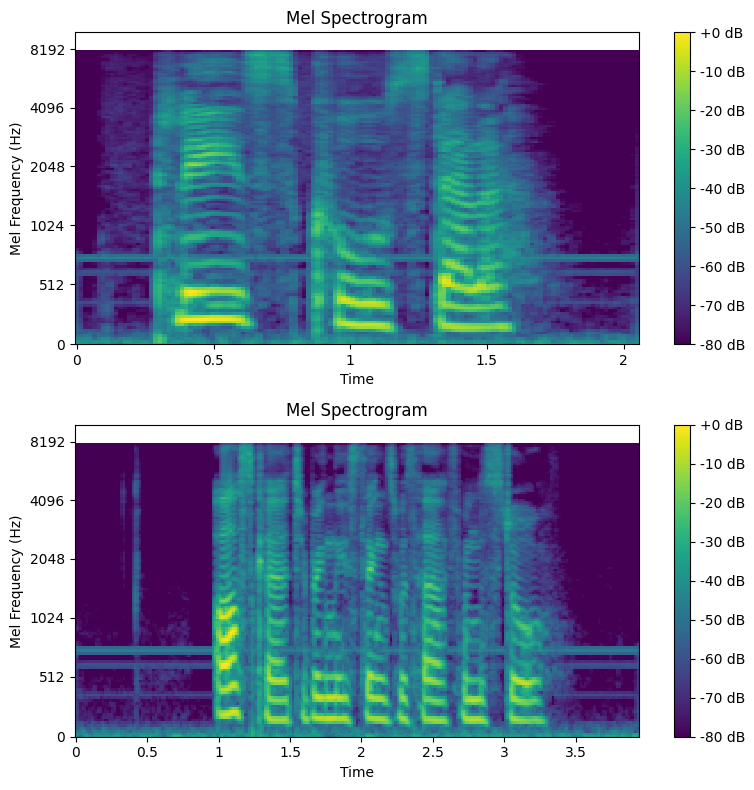

In [5]:
import torchaudio
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt


audio_processed_define, sr = torchaudio.load('out/ExpEmbedWatermark/VCTK_p225/p225_001_mic1.wav')
audio_processed, sr = torchaudio.load('out/ExpEmbedWatermark/VCTK_p225/p225_002_mic1.wav')
# 加载音频

up_wav_np = audio_processed_define[0].numpy()  # 转为 NumPy

# 计算 Mel 频谱图
mel_spec_up = librosa.feature.melspectrogram(y=up_wav_np, sr=sr, n_fft=1024, hop_length=256, n_mels=128)
mel_db = librosa.power_to_db(mel_spec_up, ref=np.max)

# 绘图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
img = librosa.display.specshow(mel_db, sr=sr, hop_length=256,
                               x_axis='time', y_axis='mel', cmap='viridis', ax=ax1)

#----------------------------------------------------

wav_np = audio_processed[0].numpy()  # 转为 NumPy

# 计算 Mel 频谱图
mel_spec = librosa.feature.melspectrogram(y=wav_np, sr=sr, n_fft=1024, hop_length=256, n_mels=128)
mel_db_no_up = librosa.power_to_db(mel_spec, ref=np.max)

img2 = librosa.display.specshow(mel_db_no_up, sr=sr, hop_length=256,
                               x_axis='time', y_axis='mel', cmap='viridis', ax=ax2)



ax1.set_title('Mel Spectrogram')
ax1.set_ylabel('Mel Frequency (Hz)')

ax2.set_title('Mel Spectrogram')
ax2.set_ylabel('Mel Frequency (Hz)')

ax1.set_ylim(0, 10000)
ax2.set_ylim(0, 10000)

fig.colorbar(img, ax=ax1, format='%+2.0f dB')

fig.colorbar(img2, ax=ax2, format='%+2.0f dB')
# plt.ylim(0,9000)
# plt.xlim(0,2.5)
plt.tight_layout()
plt.show()

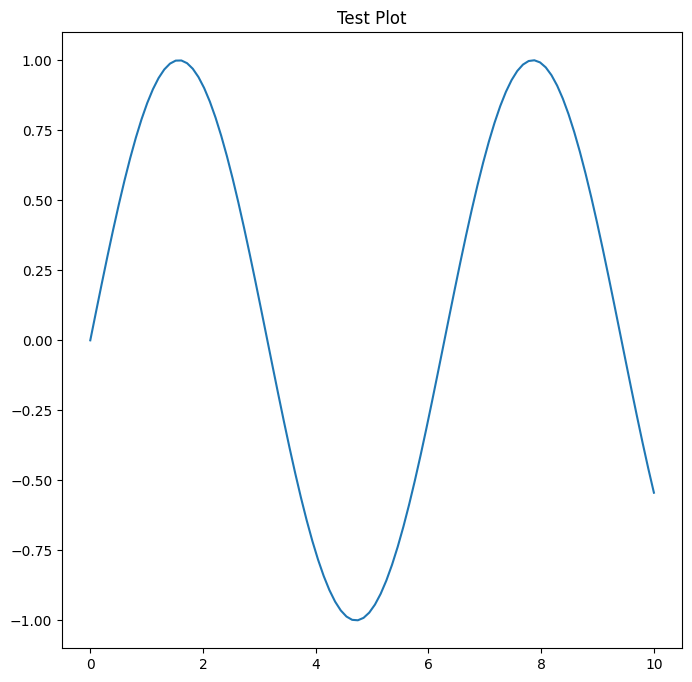

AttributeError: module 'matplotlib' has no attribute 'pyplot'

In [3]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.plot(x, y)
plt.title("Test Plot")
plt.show()


In [10]:

def get_energy_range(file_path, threshold_ratio=0.1):
    # === 加载音频 ===
    waveform, sr = torchaudio.load(file_path)
    audio = waveform[0].numpy()

    # === STFT 幅度谱 ===
    n_fft = 2048
    hop_length = 512
    S = np.abs(librosa.stft(audio, n_fft=n_fft, hop_length=hop_length))
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)  # [F]

    # === 沿时间平均，得到频率能量
    energy = np.mean(S**2, axis=1)
    energy_norm = energy / np.max(energy)

    # === 找到能量高于阈值的频段
    mask = energy_norm > threshold_ratio
    if not np.any(mask):
        return "该音频能量低于阈值"

    min_freq = freqs[mask][0]
    max_freq = freqs[mask][-1]
    return f"该音频主要能量频段：{min_freq:.1f} Hz ~ {max_freq:.1f} Hz"

# ✅ 调用
result = get_energy_range("LibriSpeech_wav/1000hz-up/19-198-0000.wav")
print(result)

该音频主要能量频段：992.2 Hz ~ 2976.6 Hz


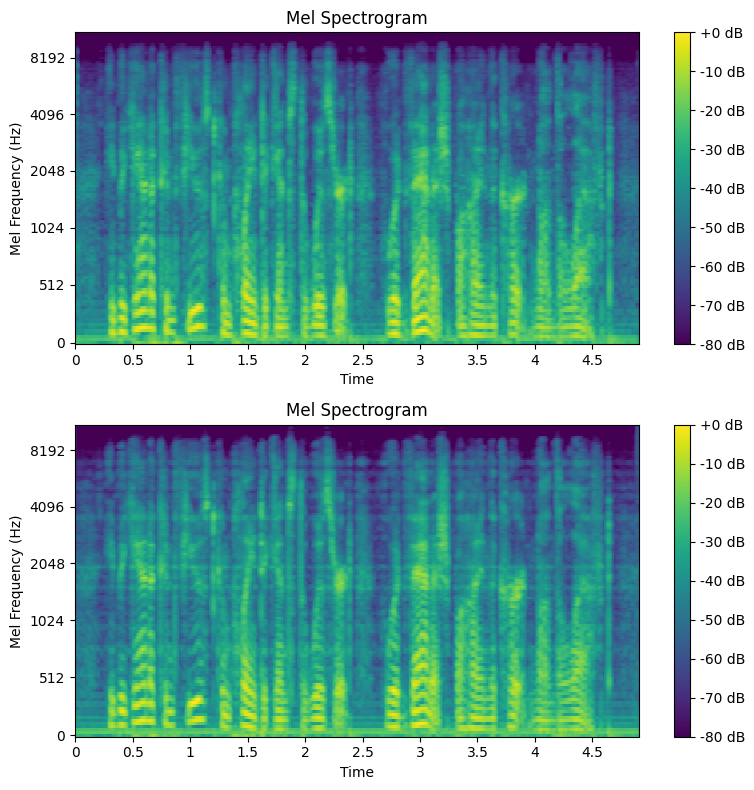

In [3]:
import torchaudio
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt


audio_processed_define, sr = torchaudio.load('my_formal_test/recover_output/timbre_61-70968-0000.wav')
audio_processed, sr = torchaudio.load('my_formal_test/test/timbre_61-70968-0000.wav')
# 加载音频

up_wav_np = audio_processed_define[0].numpy()  # 转为 NumPy

# 计算 Mel 频谱图
mel_spec_up = librosa.feature.melspectrogram(y=up_wav_np, sr=sr, n_fft=2048, hop_length=256, n_mels=128)
mel_db = librosa.power_to_db(mel_spec_up, ref=np.max)

# 绘图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
img = librosa.display.specshow(mel_db, sr=sr, hop_length=256,
                               x_axis='time', y_axis='mel', cmap='viridis', ax=ax1)

#----------------------------------------------------

wav_np = audio_processed[0].numpy()  # 转为 NumPy

# 计算 Mel 频谱图
mel_spec = librosa.feature.melspectrogram(y=wav_np, sr=sr, n_fft=2048, hop_length=256, n_mels=128)
mel_db_no_up = librosa.power_to_db(mel_spec, ref=np.max)

img2 = librosa.display.specshow(mel_db_no_up, sr=sr, hop_length=256,
                               x_axis='time', y_axis='mel', cmap='viridis', ax=ax2)



ax1.set_title('Mel Spectrogram')
ax1.set_ylabel('Mel Frequency (Hz)')

ax2.set_title('Mel Spectrogram')
ax2.set_ylabel('Mel Frequency (Hz)')
fig.colorbar(img, ax=ax1, format='%+2.0f dB')

fig.colorbar(img2, ax=ax2, format='%+2.0f dB')
# plt.ylim(0,9000)
# plt.xlim(0,2.5)
plt.tight_layout()
plt.show()

In [5]:
audio_processed_define, sr = torchaudio.load('my_formal_test/recover_output/timbre_61-70968-0000.wav')
sr

22050